# EDA: Assignment 1 part 1 

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import statsmodels.api as sm

In [2]:
folder_name = "BaselineData"
file_name = "BaselineData_V6.xlsx"

In [3]:
file_path = Path.cwd() / folder_name / file_name

### BaselineWithNoPregnacies
### Pregnancies

In [4]:
baseline = pd.read_excel(file_path, sheet_name="BaselineWithNoPregnacies")
preg = pd.read_excel(file_path,sheet_name="Pregnancies")

In [5]:
baseline.describe

<bound method NDFrame.describe of       Institution     sites            dwelling_informant  \
0              UJ  Hillbrow                Dwelling Owner   
1              UJ  Hillbrow                Dwelling Owner   
2              UJ  Hillbrow                Dwelling Owner   
3              UJ  Hillbrow                Dwelling Owner   
4              UJ  Hillbrow                Dwelling Owner   
...           ...       ...                           ...   
46107        WRHI  Hillbrow                Dwelling Owner   
46108        WRHI  Hillbrow  Household Member at Dwelling   
46109        WRHI  Hillbrow  Household Member at Dwelling   
46110        WRHI  Hillbrow  Household Member at Dwelling   
46111        WRHI  Hillbrow  Household Member at Dwelling   

      multi_floor_buildings  \
0                       Yes   
1                       Yes   
2                       Yes   
3                       Yes   
4                       Yes   
...                     ...   
46107           

In [6]:
preg.describe

<bound method NDFrame.describe of       hmr_pgh_stillbirth_month did_pregnancy_last  hmr_pgh_duration  \
0                          NaN                NaN               NaN   
1                          NaN                NaN               NaN   
2                          NaN                NaN               NaN   
3                          NaN                NaN               NaN   
4                          NaN                NaN               NaN   
...                        ...                ...               ...   
20114                      NaN                NaN               NaN   
20115                      NaN                NaN               NaN   
20116                      NaN                NaN               NaN   
20117                      NaN                NaN               NaN   
20118                      NaN                NaN               NaN   

      type_of_pregnancy spontaneous_induced_abortion         hmr_pgh_date  \
0                   NaN             

In [7]:
print("Baseline dataset shape:", baseline.shape)
print("Pregnancy dataset shape:", preg.shape)

Baseline dataset shape: (46112, 269)
Pregnancy dataset shape: (20119, 14)


In [8]:
print(baseline.describe())

       hhr_refusal_reason  hh_transfer_to  hhr_member_total  \
count                 0.0             0.0      46112.000000   
mean                  NaN             NaN          3.193702   
std                   NaN             NaN          1.927194   
min                   NaN             NaN          0.000000   
25%                   NaN             NaN          2.000000   
50%                   NaN             NaN          3.000000   
75%                   NaN             NaN          4.000000   
max                   NaN             NaN         16.000000   

       hhr_member_total_elsewhere  hhr_total_members   members_age  \
count                21477.000000       21477.000000  46107.000000   
mean                     0.085021           3.191461     27.492398   
std                      0.462243           1.845957    171.334573   
min                      0.000000           1.000000  -9999.000000   
25%                      0.000000           2.000000     18.000000   
50%         

In [9]:
print(baseline.dtypes)

Institution                                             object
sites                                                   object
dwelling_informant                                      object
multi_floor_buildings                                   object
morethan_one_building_or_structure_on_this_dwelling     object
                                                        ...   
Glue_petrol_thinners_sniffing                           object
Benzodiazepines_Valium_diazepam_alprazolam              object
Other.2                                                 object
ceu_the_informant_type                                 float64
CEU_recommendations                                    float64
Length: 269, dtype: object


# Checking for Null data

In [10]:
missing = baseline.isnull().sum().sort_values(ascending=False)
print("\nTop missing values:")
print(missing.head(20))


Top missing values:
CEU_recommendations                     46112
hhr_refusal_reason                      46112
hh_transfer_to                          46112
ceu_the_informant_type                  46112
reason_for_bs_type_other                45815
urban_weeks_lived                       45163
extreme_weather_event                   44948
other_reason_for_unemployment           44893
hmr_oth_sector                          43838
is_it_main_building                     43664
hh_reason_for_visitaware_other          43097
reason_for_visit_awareness_other        42337
hmr_new_crr_date                        40520
hmr_married                             40520
married_to_conjugal_partner             40520
urban_months_lived                      38983
given_birth_alive_but_later_died        35958
normally_where_do_you_prepare_food      35564
employer                                32473
highest_level_of_education_completed    32341
dtype: int64


### Histrograms of Missing Data 

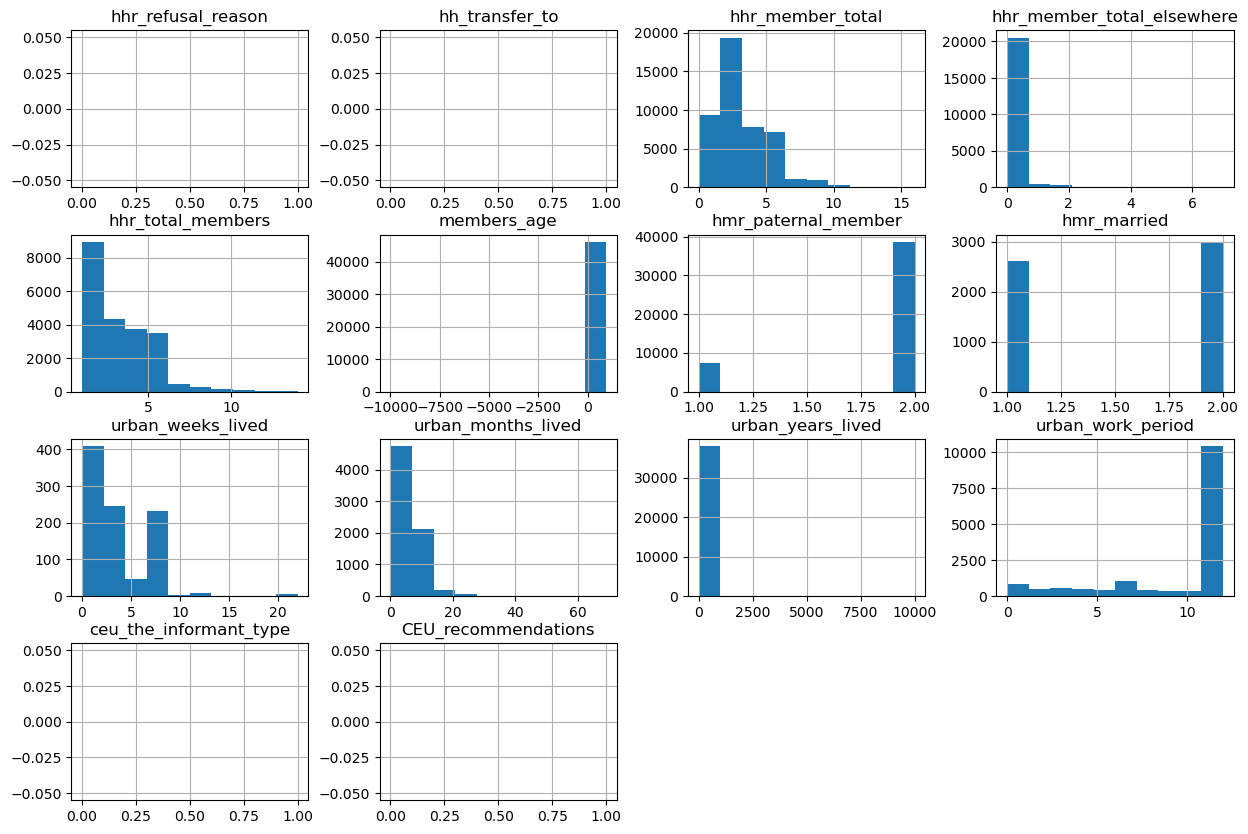

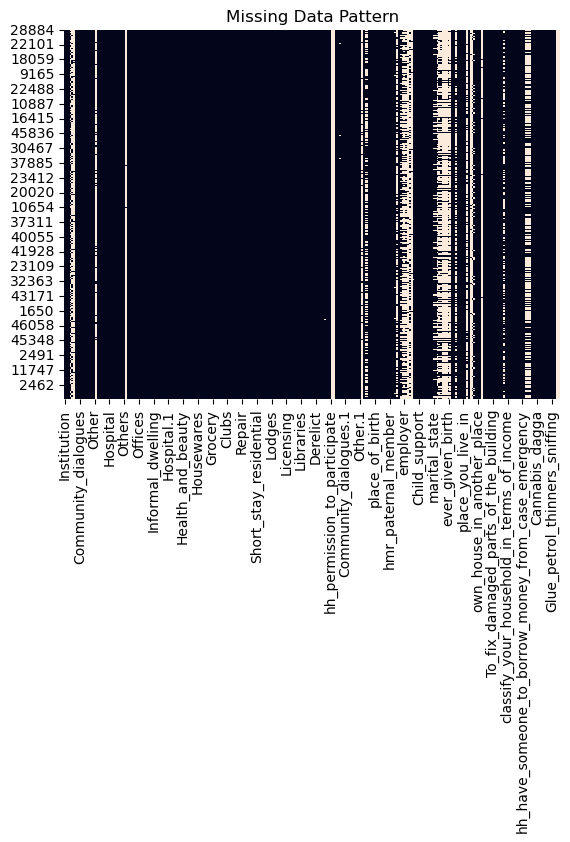

In [11]:
baseline.hist(figsize=(15,10))
plt.show()


sns.heatmap(baseline.sample(500).isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

In [12]:
site_counts = baseline["sites"].value_counts().reset_index()
site_counts.columns = ["Site", "Count"]

### Survey Distrution

In [13]:
fig = px.pie(
    site_counts,
    names="Site",
    values="Count",
    title="Distribution of Survey Records by Site",
    hole=0.3
)

fig.update_traces(textinfo="percent+label")

fig.show()

In [ ]:
melusi_df = baseline[baseline["sites"].str.lower() == "melusi"]


site_counts = melusi_df["sites"].value_counts().reset_index()
site_counts.columns = ["Site", "Count"]


In [15]:
print("Number of Melusi records:", melusi_df.shape[0])

Number of Melusi records: 8155


In [16]:
for col in melusi_df.columns:
    print(col)

print("Number of columns:", len(melusi_df.columns))

Institution
sites
dwelling_informant
multi_floor_buildings
morethan_one_building_or_structure_on_this_dwelling
is_it_main_building
aware_of_GRT_I_visiting
Roadshows
Community_dialogues
Community_meetings
Commemorative_events
Presentation_by_our_staff_at_meetings_held_by_other_organisations
Community_sport_or_music_events
Radio_programme
SMS_sent_by_our_organisation
School_based_events
Other
reason_for_visit_awareness_other
Homestead
Creche
Primary_School
Secondary_School
Clinic
Health_Care_Centre
Hospital
Church
Police_Station
Bar_Restaurant
Shop
Workshop
Social_Service_Office
Home_affairs_office
Others
reason_for_bs_type_other
Residential
Health_service
Personal_services
Retail
Entertainment
Industrial
Offices
Education
Travel_related
Public_services
Outbuilding
Inaccessible
Open_spaces
Flats
Informal_dwelling
Formal_dwelling
Cluster_housing
Hostels
Security_villages
Gated_compounds
Clinic.1
Health_centre
Hospital.1
Drop_in_centre
Place_of_safety
Alternative_therapy
Traditional_healer

In [17]:
fig = px.histogram(
    melusi_df,
    x="hhr_total_members",
    nbins=20,
    title="Distribution of Household Size in Melusi"
)

fig.show()

In [18]:
hh_size_counts = (
    melusi_df["hhr_total_members"]
    .value_counts()
    .sort_index()
    .reset_index()
)

hh_size_counts.columns = ["Household Size", "Count"]


fig = px.pie(
    hh_size_counts,
    names="Household Size",
    values="Count",
    title="Distribution of Household Size in Melusi"
)

fig.update_traces(textinfo="percent+label")

fig.show()


In [19]:
melusi_df["hhr_total_members"].describe()

count    4807.000000
mean        2.668400
std         1.654225
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         9.000000
Name: hhr_total_members, dtype: float64

In [20]:
total_population = melusi_df["hhr_total_members"].sum()

print("Estimated Population from Survey:", total_population)

Estimated Population from Survey: 12827.0


In [21]:
density_counts = melusi_df["morethan_one_building_or_structure_on_this_dwelling"].value_counts().reset_index()
density_counts.columns = ["Multiple Structures", "Count"]

fig = px.pie(
    density_counts,
    names="Multiple Structures",
    values="Count",
    title="Presence of Multiple Structures per Dwelling"
)

fig.show()

# Dwelling type distribution

In [22]:
dwelling_cols = [
    "Informal_dwelling",
    "Formal_dwelling",
    "Flats",
    "Cluster_housing",
    "Hostels"
]

dwelling_counts = pd.DataFrame({
    "Dwelling Type": dwelling_cols,
    "Count": [
        melusi_df[col].astype(str).str.strip().str.lower().eq("yes").sum()
        for col in dwelling_cols
    ]
})

fig = px.bar(
    dwelling_counts,
    x="Dwelling Type",
    y="Count",
    title="Distribution of Dwelling Types in Melusi",
    text="Count"
)

fig.update_layout(xaxis_title="Dwelling Type", yaxis_title="Number of Records")
fig.show()

In [23]:
num_households = melusi_df.shape[0]

print("Number of Surveyed Households:", num_households)

Number of Surveyed Households: 8155


In [24]:
dwelling_cols = [
    "Informal_dwelling",
    "Formal_dwelling",
    "Flats",
    "Cluster_housing",
    "Hostels"
]

# Standardise Yes/No values
for col in dwelling_cols:
    melusi_df[col] = (
        melusi_df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# Create single dwelling type column
melusi_df["dwelling_type"] = melusi_df[dwelling_cols].idxmax(axis=1)

/var/folders/7h/t0f4h_k54vv9j6759pcclxgw0000gn/T/ipykernel_29596/1348214237.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/7h/t0f4h_k54vv9j6759pcclxgw0000gn/T/ipykernel_29596/1348214237.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/7h/t0f4h_k54vv9j6759pcclxgw0000gn/T/ipykernel_29596/1348214237.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [25]:
fig = px.box(
    melusi_df,
    x="dwelling_type",
    y="hhr_total_members",
    title="Household Size Distribution by Dwelling Type in Melusi",
    labels={
        "dwelling_type": "Dwelling Type",
        "hhr_total_members": "Household Size"
    }
)

fig.show()

In [26]:
hh_by_dwelling = (
    melusi_df
    .groupby("dwelling_type")["hhr_total_members"]
    .mean()
    .reset_index()
)

hh_by_dwelling.columns = ["Dwelling Type", "Average Household Size"]

print(hh_by_dwelling)

       Dwelling Type  Average Household Size
0              Flats                2.714286
1    Formal_dwelling                1.666667
2  Informal_dwelling                2.669587


In [27]:
fig = px.bar(
    hh_by_dwelling,
    x="Dwelling Type",
    y="Average Household Size",
    title="Average Household Size by Dwelling Type",
    text="Average Household Size"
)

fig.show()

In [28]:
pop_by_dwelling = (
    melusi_df
    .groupby("dwelling_type")["hhr_total_members"]
    .sum()
    .reset_index()
)

pop_by_dwelling.columns = ["Dwelling Type", "Total Population"]

fig = px.pie(
    pop_by_dwelling,
    names="Dwelling Type",
    values="Total Population",
    title="Population Distribution by Dwelling Type"
)

fig.show()

In [29]:
hostel_counts = melusi_df["Hostels"].value_counts().reset_index()
hostel_counts.columns = ["Hostel", "Count"]

hostel_counts["Hostel"] = hostel_counts["Hostel"].map({
    1: "Hostel",
    0: "Non-Hostel"
})

fig = px.pie(
    hostel_counts,
    names="Hostel",
    values="Count",
    title="Proportion of Hostel vs Non-Hostel Dwellings in Melusi"
)

fig.update_traces(textinfo="percent+label")

fig.show()

In [30]:
outbuilding_counts = (
    melusi_df["Outbuilding"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "yes": "Yes",
        "no": "No",
        "nan": "Missing",
        "": "Missing"
    })
    .value_counts()
    .reset_index()
)

outbuilding_counts.columns = ["Outbuilding", "Count"]

fig = px.pie(
    outbuilding_counts,
    names="Outbuilding",
    values="Count",
    title="Distribution of Outbuilding in Melusi"
)
fig.update_traces(textinfo="percent+label")
fig.show()

### Heat map

In [31]:
corr_df = melusi_df.copy()

corr_df = corr_df.replace({
    "Yes": 1, "No": 0,
    "yes": 1, "no": 0
})


corr_df = corr_df.select_dtypes(include="number")

/var/folders/7h/t0f4h_k54vv9j6759pcclxgw0000gn/T/ipykernel_29596/1572220922.py:3: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [32]:
corr_matrix = corr_df.corr()

In [33]:
fig = px.imshow(
    corr_matrix,
    color_continuous_scale="RdBu_r",
    title="Correlation Heatmap of Melusi Survey Variables"
)

fig.update_layout(
    width=900,
    height=900
)

fig.show()

In [34]:
population_corr = (
    corr_df.corr()["hhr_total_members"]
    .sort_values(ascending=False)
    .reset_index()
)

population_corr.columns = ["Feature", "Correlation"]

print(population_corr.head(20))

                          Feature  Correlation
0               hhr_total_members     1.000000
1                hhr_member_total     0.971503
2             mother_member_of_hh     0.522424
3             parks_openspace_use     0.454633
4             father_member_of_hh     0.422516
5                          Grants     0.391674
6                   Child_support     0.379391
7             sole_use_of_kitchen     0.291148
8   recipient_of_government_grant     0.263764
9               urban_weeks_lived     0.252076
10             urban_months_lived     0.225036
11               ever_given_birth     0.180273
12   regular_partner_member_of_hh     0.179371
13                 if_partnership     0.176122
14     hhr_member_total_elsewhere     0.160677
15         Income_from_employment     0.133583
16            is_it_main_building     0.121772
17     Employed_a_causal_labourer     0.116125
18             Community_meetings     0.108411
19     To_accommodate_more_people     0.104850


In [35]:
top_corr = population_corr.head(15)

fig = px.bar(
    top_corr,
    x="Correlation",
    y="Feature",
    orientation="h",
    title="Top Features Correlated with Household Population"
)

fig.show()